여기서는 LLM이 자신이 하고 있는 일을 잘 하고 있는지 셀프로 검증하는 self-rag를 학습한다.

In [1]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embeddings,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})


In [2]:
# START -> RETRIEVE -> GENERATE -> END

from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)

In [3]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}    

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [5]:
from langchain import hub

generate_prompt = hub.pull('rlm/rag-prompt')
generate_llm = ChatOpenAI(model='gpt-4o', max_tokens=100)
def generate(state: AgentState) -> AgentState:
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response.content}

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [6]:
from langchain import hub
from typing import Literal

# 질문과 document의 연관성이 얼마나 되는지 확인하는 rag-document-relevance 프롬프트
doc_relevance_prompt = hub.pull('langchain-ai/rag-document-relevance')

# self-rag에서는 END를 호출을 해야 하는데, END는 노드가 아니기 떄문에, Literal을 해도 에러가 발생한다. 따라서 엣지에서 처리해야 한다.
# 질문이 문서와 얼마나 연관성이 있는지 체크하는 노드
def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    if response['Score'] == 1:
        return 'relevant'
    return 'irrelevant'

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [7]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
    사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    사전: {dictionary}
    질문: {{query}}
"""
)

# 사용자의 질문을 변경해주는 노드
def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    return {'query': response}


In [8]:
from langchain import hub

hallucination_prompt = hub.pull('langchain-ai/rag-answer-hallucination')

# 할루시네이션이 발생하였는지를 체크하는 노드
def check_hallucination(state: AgentState) -> Literal['hallucinated', 'not hallucinated']:
    answer = state['answer']
    context = state['context']
    hallucination_chain = hallucination_prompt | llm
    response = hallucination_chain.invoke({'student_answer': answer, 'documents': context})
    if response['Score'] == 1:
        return 'hallucinated'
    return 'not hallucinated'


/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [9]:
from langchain import hub

helpfulness_prompt = hub.pull('langchain-ai/rag-answer-helpfulness')

# 질문과 답변이 연관이 있는지 체크하는 노드
def check_helpfulness_grader(state: AgentState) -> Literal['helpful', 'unhelpful']:
    query = state['query']
    answer = state['answer']
    helpfulness_chain = helpfulness_prompt | llm
    response = helpfulness_chain.invoke({'question': query, 'student_answer': answer})
    if response['Score'] == 1:
        return 'helpful'
    return 'unhelpful'


def check_helpfulness(state: AgentState):
    return state

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [10]:
# 할루시네이션을 검증하는 prompt의 테스트

query = '연봉 5천만원인 거주자의 소득세는 얼마인가요?'

context = retriever.invoke(query)
generate_state = {'query': query, 'context': context}
answer = generate(generate_state)

# langchain 할루시네이션 프롬프트를 사용 시 할루시네이션이 발생했다고 판단한다.
# 문서에 있는 내용을 근거로 해서 답변을 해서 답변이 길어서로 유추된다.
# langchain에서 제공하는 prompt를 사용하지 않고, 직접 prompt를 수정해서 사용해야 할것 같다.
hallucination_state = {'answer': answer, 'context': context}

check_hallucination(hallucination_state)

'not hallucinated'

In [11]:
# 할루시네이션을 검증하는 prompt의 테스트

query = '연봉 5천만원인 거주자의 소득세는 얼마인가요?'

context = retriever.invoke(query)
generate_state = {'query': query, 'context': context}
answer = generate(generate_state)

helpfulness_state = {'query': query, 'answer': answer}

check_helpfulness(helpfulness_state)

{'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?',
 'answer': {'answer': '연봉 5천만원인 거주자의 소득세는 다음과 같이 계산됩니다. 5천만원은 과세표준이 1,400만원을 초과하고 8,800만원 이하인 구간에 해당하므로, 5천만원을 초과하는 금액에 대해 24%의 세율이 적용됩니다. 따라서 소득세는 624만원입니다.'}}

In [12]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('check_helpfulness', check_helpfulness)


In [13]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': END
    }
)
graph_builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
        'hallucinated': 'generate',
        'not hallucinated': 'check_helpfulness'
    }
)
graph_builder.add_conditional_edges(
    'check_helpfulness',
    check_helpfulness_grader,
    {
        'helpful': END,
        'unhelpful': 'rewrite'
    }
)
graph_builder.add_edge('rewrite', 'retrieve')

In [14]:
graph = graph_builder.compile()

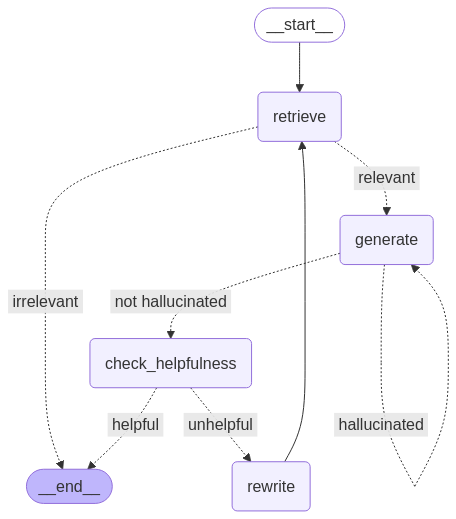

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [16]:
# 관련이 없는 질문을 하면 끝난다.
initial_state = {'query': '안녕하세요'}
graph.invoke(initial_state)


{'query': '안녕하세요',
 'context': [Document(id='6d83d22a-0bb6-42b9-a7d9-bfc2cc2cc5a2', metadata={'source': './documents/income_tax.txt'}, page_content='5. 삭제<2014. 1. 1.>\n6. 삭제<2014. 1. 1.>\n7. 삭제<2014. 1. 1.>\n8. 제104조의3에 따른 비사업용 토지  \n법제처  92    국가법령정보센터\n소득세법\n양도소득세표준\n|  구분           |  세율                              |\n|-----------------|------------------------------------|\n| 1,400만원 이하  | 16% 세트                           |\n| 1,400만원 초과  | 22만원 + (1,400만원 초과액 × 25%) 세트 |\n| 5,000만원 이하  | 1,124만원 + (5,000만원 초과액 × 34%) 세트 |\n| 5,000만원 초과  | 2,416만원 + (8,800만원 초과액 × 45%) 세트 |\n| 1억 원 초과     | 5,206만원 + (1억5천만원 초과액 × 48%) 세트 |\n| 3억 원 이하     | 1,942,406만원 + (3억 원 초과액 × 50%) 세트 |\n| 5억 원 이하     | 2,942,406만원 + (5억 원 초과액 × 52%) 세트 |\n| 10억 원 이하    | 4,942,406만원 + (10억 원 초과액 × 55%) 세트 |\n9. 제94조제1항제1호 및 다목에 따른 자산 중 자산의 비사입용 토지의 보유 현황을 고려하여 대통령령으로 정하는 자산\n양도소득세 자산\n|  구분           |  세율                             |\n|-----------------|-----------------------------------|\n| 1,400만원 이하 

In [17]:
initial_state = {'query': '연봉 5천만원의 거주자의 세금'}
graph.invoke(initial_state)

{'query': '거주자의 연봉 5천만원에 대한 세금',
 'context': [Document(id='5db07ddf-368f-4b8e-94a4-b8c88f77765f', metadata={'source': './documents/income_tax.txt'}, page_content='[본조신설 2016. 12. 20.]\n제118조의18 삭제 <2020. 12. 29.>\n[시행일: 2025. 1. 1.] <제118조의18>\n제43장 비거주자의 납세의무\n<개정 2009. 12. 31.>\n제67장 비거주자에 대한 세액 계산 충정\n<개정 2009. 12. 31.>\n제119조(개거주자의 국외전출속)\n1., 2013. 1. 1., 2015. 12. 23, 2016. 12. 20. 2018. 12. 31, 2019. 12. 31, 2020. 12. 29. \n국외전출 이자소득: 다음 각 목의 어느 하나에 해당하는 소득으로서 제16조제1항에서 규정하는 이자(같은 항 제7호 소득을 제외한다. 다만, 거주자 또는 내국법인의 국외사업장을 위하여 그 국외사업장이 직접 차입한 자금이 이자임을 제외한다.\n가. 국가, 지방자치단체(지방자치단체조합을 포함한다) 이하 제156조제1항제1호마목에서 간다. 거주자, 내국법인, ‘법인세법’ 제30조에서 규정하는 외국법인의 국외사업장 등 제120조에서 규정하는 비거주자와의 거래로부터 받는 소득\n국내연배소득: 내국법인 또는 법인이 아닌 단체는 그 밖의 국내외서 재하는 자료부터 받는 다음 각 목의 소득\n가. 제16조제1항제2호에 따른 파생결합사채로부터의 이익\n나. 제17조제1항에 따른 비과세소득(같은 항 제6호 다른 소득을 제외한다)\n다. 제21조제6항제4호에 따른 집합투자증권의 환매로 발생한 이익 또는 적격집합투자기구로부터의 이익 중 대통령령으로 정하는 이익\n라. 제37조의6제1항제5호에 따른 파생결합상품으로부터의 이익 중 대통령령으로 정하는 이익  \n국내원천 부동산소득: 국내에 있는 부동산 또는 부동산실양 권리와 